#Healthcare Predictive Analytics (Disease Detection)
Predicting Risk of Heart Disease Using Machine Learning

##Introduction

Healthcare predictive analytics uses machine learning techniques to analyze medical data and predict the likelihood of diseases. Early disease prediction helps doctors take preventive measures and improves patient outcomes.

In this project, we build a machine learning model that predicts whether a patient is at risk of diabetes based on medical attributes such as glucose level, BMI, age, and blood pressure.

##Objectives


>To analyze healthcare data and identify patterns related to disease risk.

>To preprocess and normalize medical data for consistency.

>To apply machine learning classification models for disease prediction.

>To evaluate model performance using different metrics.

>To identify the most important health factors influencing disease prediction.

>To highlight ethical considerations when handling healthcare data.

##Dataset Description

Dataset: Pima Indians Diabetes Dataset

Source: Kaggle

This dataset contains medical records of female patients and is commonly used for diabetes prediction research.

>Rows: 768 patients

>Columns: 9 features

>Target variable: Outcome (0 = No Diabetes, 1 = Diabetes)

>Type: Healthcare / Medical classification dataset

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

data = pd.read_csv("diabetes.csv")

data.head()

Saving diabetes.csv to diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##Exploratory Data Analysis (EDA)

In [3]:
#Check dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
#Check statistical summary
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
#Check missing values
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##Data Visualization

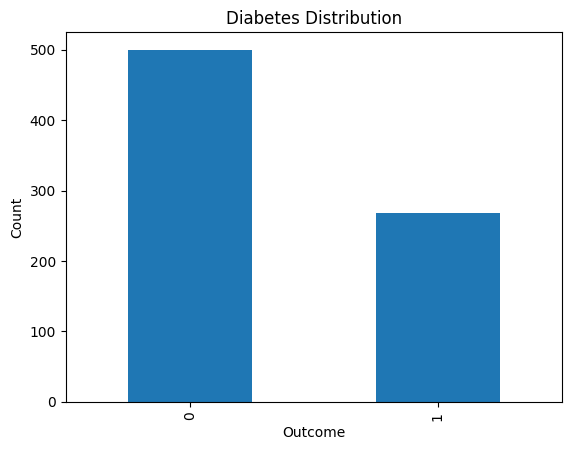

In [6]:
#Distribution of diabetes cases
data['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

##Feature Selection

In [7]:
#Separating features and target variable.
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

##Train-Test Split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Data Normalization

In [9]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

##Model Training

In [11]:
#Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

In [12]:
#Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

##Model Evaluation

In [13]:
#Random Forest Performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7207792207792207
[[77 22]
 [21 34]]
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [14]:
#Logistic Regression Performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7532467532467533
[[79 20]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



##Feature Importance Analysis

In [15]:
importances = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
1,Glucose,0.258864
5,BMI,0.169984
7,Age,0.140931
6,DiabetesPedigreeFunction,0.123768
2,BloodPressure,0.088134
0,Pregnancies,0.076551
4,Insulin,0.076122
3,SkinThickness,0.065646


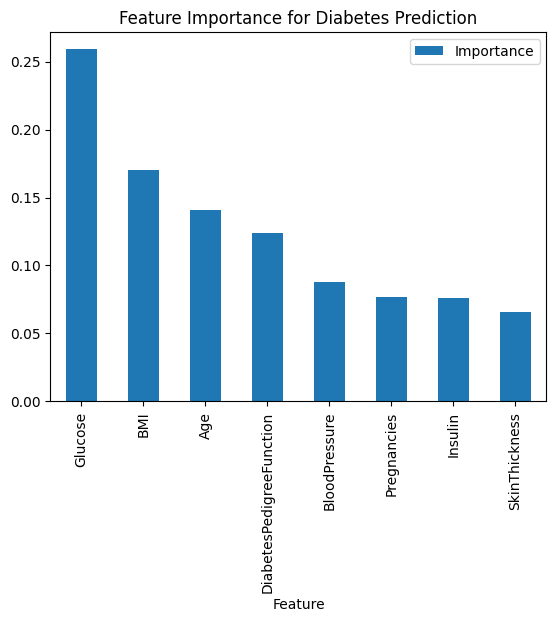

In [16]:
#Visualization of Important Features
importance_df.plot(x="Feature", y="Importance", kind="bar")

plt.title("Feature Importance for Diabetes Prediction")
plt.show()

#Conclusion

In this project, we developed a machine learning model for predicting diabetes risk using healthcare data.

##Key findings:

>Machine learning models can effectively predict disease risk using medical features.

>Random Forest provided strong performance compared to Logistic Regression.

>Important predictors included Glucose level, BMI, and Age.

>Predictive analytics can assist healthcare professionals in early disease detection.

However, machine learning models should not replace medical diagnosis and must be used responsibly with proper ethical considerations.